# I- Basic statistical concepts

When studying a **population**, it is impossible to assess each individual present in the studied group. We therefore refer to a representative **sample** of the population (ie. a large enough number of individuals chosen at random from the population). 

Any parameter measured and computed from a sample is an **estimate**. As such, it is not perfectly precise: there is an unknown error to every estimate. The goal of statistics is to compute **reliable** estimates and therefore assess the precision of a given statistic. 

## 1.1) Describing distributions and sampling precision

When collecting data on a parameter, we want to know how it is **distributed** across the population, that is the proportion of individuals in the population exhibit this parameter or a measurement of this parameter. A good insight of a parameter distribution in a sample is given by histograms. One of the goals of statistics is to infer the **mass function of this distribution** over a large number of individuals (ie. when $N \to \infty$ ) in order to draw insightfull **statistics** over the population. 

In [2]:
# Load and preview the Sparrow Size dataset
SparrowData = read.table("../data/SparrowSize.txt", header = TRUE)
head(SparrowData)

,BirdID,Year,Tarsus,Bill,Wing,Mass,Sex,Sex.1
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,1,2002,16.9,NA,76,23.60,0,female
2,2,2001,16.8,NA,76,27.50,1,male
3,2,2002,17.2,NA,76,28.10,1,male
4,2,2003,17.5,13.5,76,27.75,1,male
5,2,2004,17.8,13.4,77,26.50,1,male
6,2,2004,17.7,13.1,78,26.00,1,male


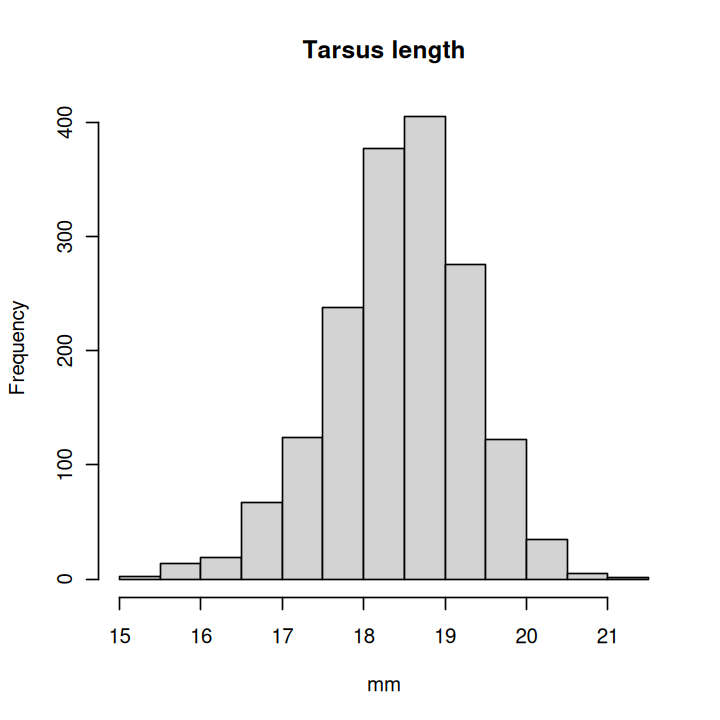

In [3]:
options(repr.plot.width = 6, repr.plot.height = 6)  # width, height in inches
hist(SparrowData$Tarsus, main = "Tarsus length", xlab = "mm")

To describe data distribution, we use two main concepts: 
1. **Centrality** = Describes *where the center or typical value of a data distribution lies* — that is, the point around which the data tend to cluster.
   
2. **Spread** = Quantifies *how scattered or variable the data values are around the center* — how much they differ from each other.

### 1.1.1) Centrality 
Common measures of centrality include:

- **Mean** = arithmetic average of the dataset
- **Median** = middle value when data are ordered 
- **Mode** = most frequent value 

While **mean** measures the average of a dataset and is the mathematically most precise measure of centrality, it is *sensitive to outliers*. On the contrary, **median** and **mode** are less precise but more robust to outliers. Median is usually used for **numeric** data whilst mode is rather used in the context of **categorical** data.

#### Mean and median
Since we have continuous numeric data, *most values will only occur once*. We will therefore have a hard time computing the mode. Let us compute the mean and median of the Tarsus length only.

***NB:*** Don't forget to remove NA values using *na.rm = TRUE*, otherwise the mean() and median() functions will return "NA"! **When values are missing**, one can bootstrap the data, that is either ***(i)** remove NAs* or ***(ii)** infer missing values* to fit the estimated distribution.

In [4]:
mean_tarsus = mean(SparrowData$Tarsus, na.rm = TRUE)
median_tarsus = median(SparrowData$Tarsus, na.rm = TRUE)

print(paste("Mean Tarsus length:", mean_tarsus))
print(paste("Median Tarsus length:", median_tarsus))

[1] "Mean Tarsus length: 18.5233531018576"
[1] "Median Tarsus length: 18.60000038"


We can see that the mean and the median are almost identical. This means that the data is **centered**, *ie.* there are not many outliers.

#### Effect of bin size on data centrality
Let's look how the distribution, and particularly the centrality of the distribution, changes when we make the number of breaks vary int he histogram. 

***NB:*** In a histogram, the **bins** are the intervals in which numerical data is classified and the **breaks** are the successive edges of the bins.

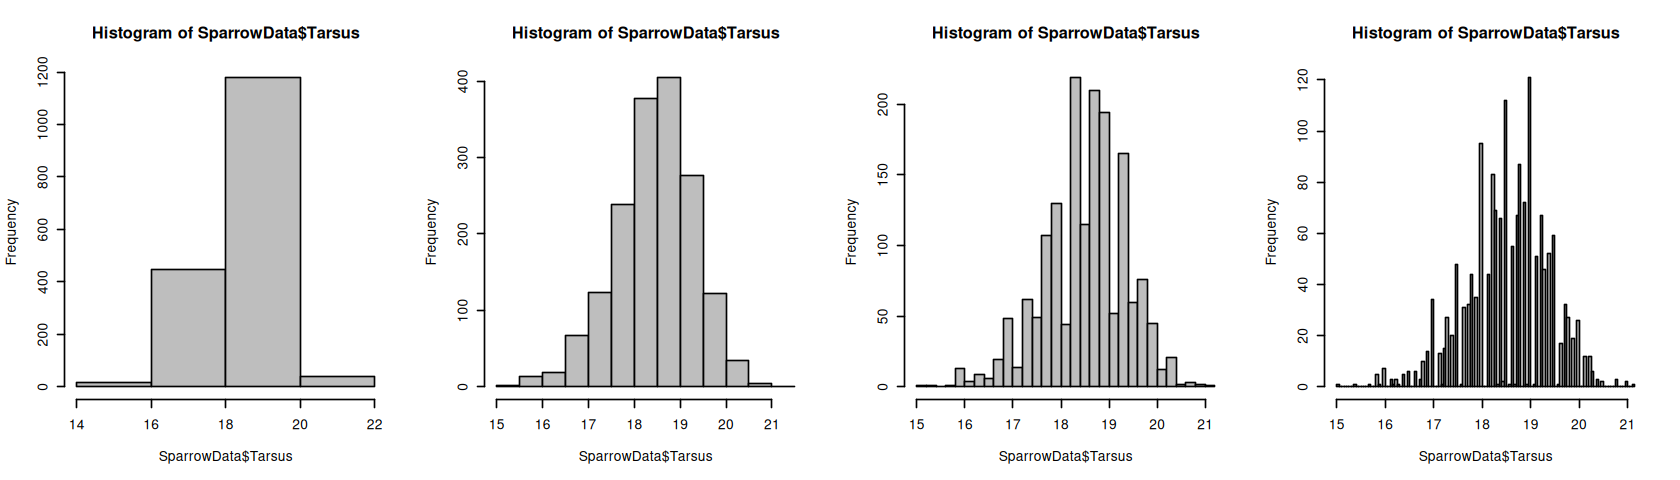

In [5]:
par(mfrow = c(1,4)) # creates a 1x4 plotting area
options(repr.plot.width = 14, repr.plot.height = 4)
hist(SparrowData$Tarsus, breaks = 3, col = 'grey')
hist(SparrowData$Tarsus, breaks = 10, col = 'grey')
hist(SparrowData$Tarsus, breaks = 30, col = 'grey')
hist(SparrowData$Tarsus, breaks = 100, col = 'grey')

The higher the number of breaks in the histogram, the more we can observe **odd gaps** in the diagram. Indeed, the number of bins increases, the resolution of the histogram increases accordingly. At some point, **the resolution of the diagram will become higher than that of the measuring device**, which leads to some values lacking in the sampled population. 

#### Mode
However, this gives us a better insight of what the mode could possibly be. Let us write a function to compute the mode of this dataset.

In [6]:
library(tidyverse)

SparrowData$RoundedTarsus = round(SparrowData$Tarsus, digit = 2)
OrderedValues = SparrowData %>%count(RoundedTarsus, sort = TRUE)
head(OrderedValues)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


,RoundedTarsus,n
,<dbl>,<int>
1,19.0,121
2,18.5,112
3,18.0,95
4,18.8,87
5,NA,85
6,18.2,83


This script tells us that the most freauent value encountered in this dataset, with resolution down to the first decimal, is 19.0. However, we can also note that the 5th most frequent value is an 'NA', which ;ight show up as mode in some datasets. Always think of removing the NAs first!

The function goes as follow:

In [7]:
ModeFunc = function(x){
  x = na.omit(x) # remove NAs
  x = round(x, digit = 1) # round to 1 decimal place
  ux = unique(x) # get unique values
  ux[which.max(tabulate(match(x, ux)))] # return the most frequent value
}   

mode_tarsus = ModeFunc(SparrowData$RoundedTarsus)
print(paste("Mode Tarsus length:", mode_tarsus))

[1] "Mode Tarsus length: 19"


### 1.1.2) Spread

Spread is usually measured using the follwing metrics:

- **Range** = Minimum and maximum values of the dataset
- **Variance** = Average of squared deviation from the mean
- **Standard deviation** = Square root of variance. Measures the *typical distance from the mean*.
- **Sum of Squares** = Sum of the squared distance to the mean. Captures the *total deviation from the mean*.
- **Interquartile range** = Range between the 25th and the 75th percentile.


#### Range
The **range** of the data is the first natural measure of data spread. However, it does not give us any insights on how clumped the data is around the central values, that is how much it **deviates**.

In [8]:
# Compute the range of Tarsus lengths
range_tarsus = range(SparrowData$Tarsus, na.rm = TRUE)
print(paste("Range of Tarsus lengths:", paste(range_tarsus, collapse = " - ")))

# Check range function
min_tarsus = min(SparrowData$Tarsus, na.rm = TRUE)
max_tarsus = max(SparrowData$Tarsus, na.rm = TRUE)
print(paste("Min Tarsus length:", min_tarsus))
print(paste("Max Tarsus length:", max_tarsus))

[1] "Range of Tarsus lengths: 15 - 21.10000038"
[1] "Min Tarsus length: 15"
[1] "Max Tarsus length: 21.10000038"


#### Variance, standard deviation and sum of squares
All these metrics are linked mathematically. Starting with the *sum of squares*, it is defined as:
$$ SS = \sum_{i=1}^n (x_i - \bar{x})^2$$
with $\bar{x}$ the arithmetic mean of the data.

This metric measures **the total deviation from the mean**. We use the square of the distance to the mean in order to *avoid the compensation of positive and negative distances* and also to *emphasize larger deviations* in order to account for outliers.

The variance is derived derectly from the sum of squares:
$$ Var = \frac{SS}{n-1}  = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2$$
It refers to the *average value of squared deviation*. 

Variance is also denoted $\sigma^2$ because of the definition of *standard deviation* $\sigma$:
$$ \sigma = \sqrt{Var} = \sqrt{\frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n-1}}$$
This measures typical distance to the mean. 

In [9]:
VarTarsus = var(SparrowData$Tarsus, na.rm = TRUE)
SDTarsus = sd(SparrowData$Tarsus, na.rm = TRUE)

print(paste("Variance of Tarsus lengths:", VarTarsus))
print(paste("Standard Deviation of Tarsus lengths:", SDTarsus))

# Check calculations
DataWithoutNA = na.omit(SparrowData$Tarsus)
MeanTarsus = mean(DataWithoutNA, na.rm = TRUE)
SS = sum((DataWithoutNA - MeanTarsus)^2, na.rm = TRUE)
N = length(DataWithoutNA)
VarTarsus_check = SS / (N - 1)
SDTarsus_check = sqrt(VarTarsus_check)

print(paste("Checked Variance of Tarsus lengths:", VarTarsus_check))
print(paste("Checked Standard Deviation of Tarsus lengths:", SDTarsus_check))

[1] "Variance of Tarsus lengths: 0.740405913517285"
[1] "Standard Deviation of Tarsus lengths: 0.860468426798616"
[1] "Checked Variance of Tarsus lengths: 0.740405913517285"
[1] "Checked Standard Deviation of Tarsus lengths: 0.860468426798616"


integer(0)

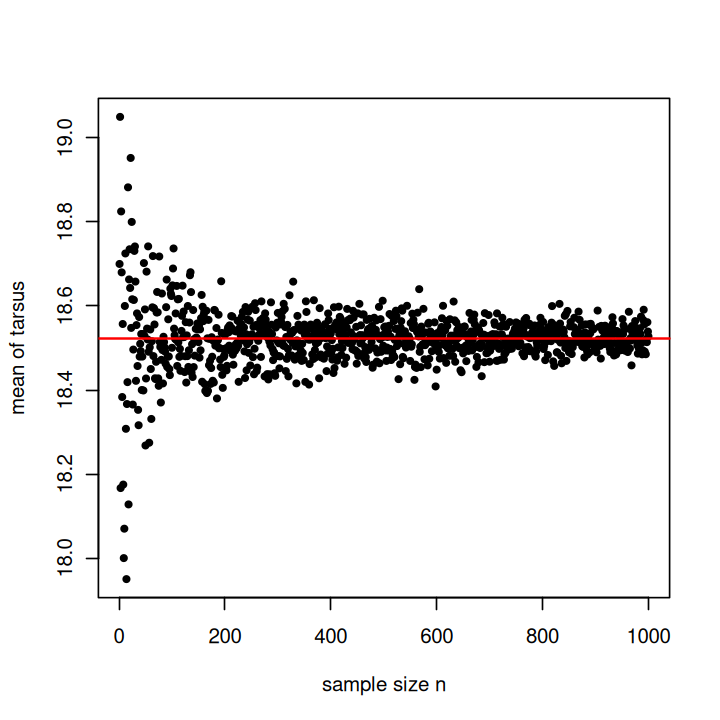

In [10]:
set.seed(123)
d = na.omit(SparrowData$Tarsus)
n <- 1:1000
means <- sapply(n, function(i) mean(sample(d, i, replace = TRUE)))

# Tracer
options(repr.plot.width = 6, repr.plot.height = 6)  # width, height in inches
plot(x = n,y = means,
     xlab = "sample size n",
     ylab = "mean of tarsus",
     pch = 19, cex = 0.6, col = "black") + abline(h = mean(d), col = "red", lwd = 1.5)

This graph illustrates the *convergence of the sampled means towards the population mean* ie. the **law of large numbers**. This law states that the standard deviation of a sample decreases when the sample size increases, making centrality more consipicuous.

#### Z-scores and quantiles
**Z-transformation** refers to the transformation of any dataset to a distribution with *mean 0 and standard deviation 1*. 

Consider a sample $y$ of mean $\bar{y}$ and standard deviation $\sigma_y$. The **z-transformed** or **normalized** version, also called **z-score** of the distribution is defined as:
$$ z = \frac{ y - \bar{y}}{\sigma_y}$$
This tells you *how many standard deviations a data point is from the mean of the distribution*.

The embedded R function to normalize a sample is *scale()*.

BirdID,Year,Bill,Wing,Mass,Sex,Sex.1,RoundedTarsus,Type,Value
<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>
2,2003,13.5,76,27.75,1,male,17.5,Tarsus,17.5000000
2,2003,13.5,76,27.75,1,male,17.5,Z.Tarsus,-1.3339499
2,2004,13.4,77,26.50,1,male,17.8,Tarsus,17.7999992
2,2004,13.4,77,26.50,1,male,17.8,Z.Tarsus,-0.9676541
2,2004,13.1,78,26.00,1,male,17.7,Tarsus,17.7000008
2,2004,13.1,78,26.00,1,male,17.7,Z.Tarsus,-1.0897511


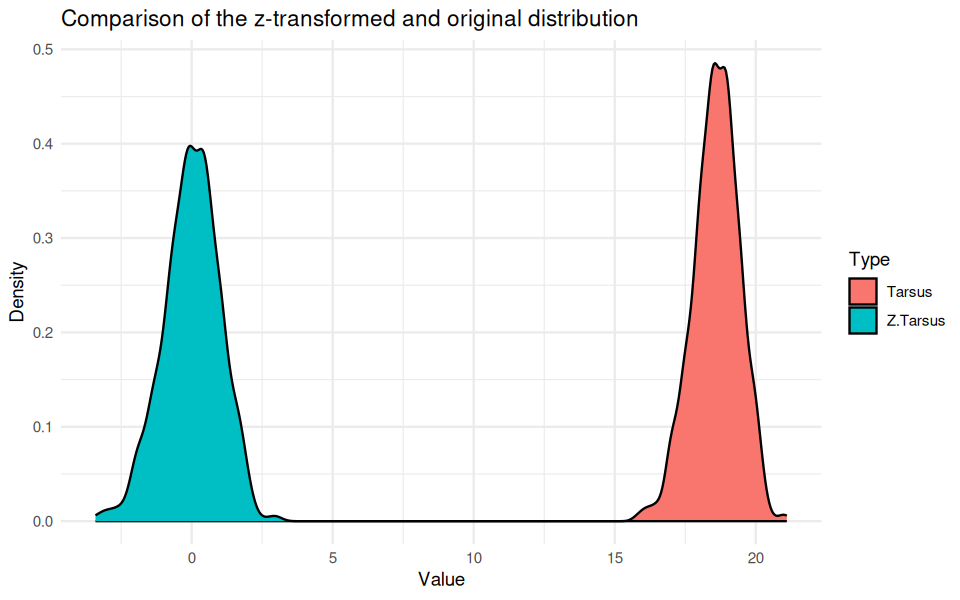

In [11]:
library(ggplot2)
library(tidyr)

# remove na and create a z-transformed column
df <- na.omit(SparrowData)
df$Z.Tarsus = as.numeric(scale(df$Tarsus))

# create a long format table
df_long <- pivot_longer(df, cols = c(Tarsus, Z.Tarsus),
                        names_to = "Type", values_to = "Value")
head(df_long)

# plot the transformed and original distribution
options(repr.plot.width = 8, repr.plot.height = 5)  # width, height in inches
ggplot(df_long, aes(x = Value, fill = Type)) +
  geom_density() +
  labs(title = "Comparison of the z-transformed and original distribution", x = "Value", y = "Density") +
  theme_minimal()

As one can see here, the normalized distribution is centered in 0 and has a variance of 1. 

The reason we perform z-transformations are, among others, to:
1. **standardize data** for better comparison across distributions
2. **identify outliers** ($\|z\| > 3$ is a potential outlier)
3. **hypothesis testing** like z-test, t-tests, etc.
4. **PCA** relies on standardized variables

The reason we call this a z-score is because the standard normal distribution is also known as *z distribution*. 

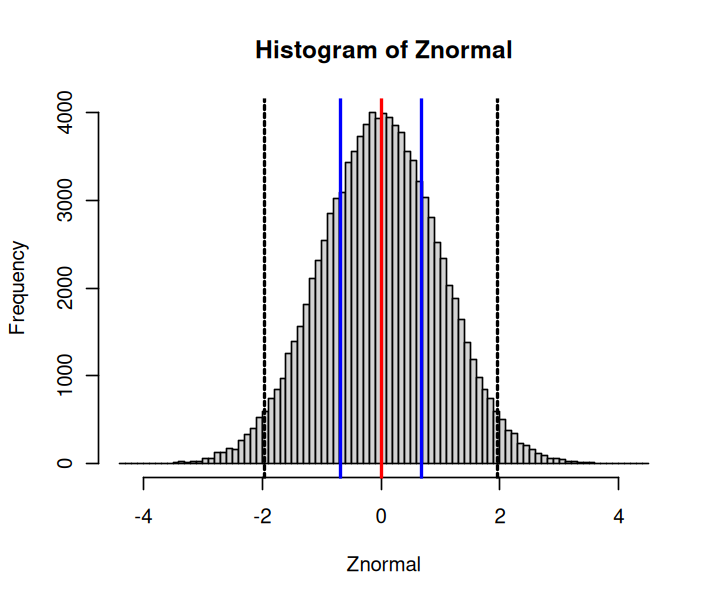

In [12]:
Znormal = rnorm(100000)
options(repr.plot.width = 6, repr.plot.height =5)  # width, height in inches
hist(Znormal, breaks = 100)
abline(v = qnorm(c(0.25, 0.5, 0.75)), lwd = 2, col= c("blue", "red", "blue"))
abline(v = qnorm(c(0.025, 0.975)), lwd = 2, lty = "dashed")

In [13]:
summary(Znormal)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-4.383516 -0.679119  0.001341 -0.000463  0.674963  4.453279 

The **quantiles** refer to the respective cut-offs of the data distribution at a given probability. When these cut-offs divide the data in 4 parts, we calltehm **quartiles**. For instance the median is the *second quartile* as 50% of the data points are excluded. The *first* and *third* quartiles correspond to the value under which 25% and 75% of the data respectively are located.

The **interquartile range** is a measure of spread in a distribution.

Other very important quantiles are the **2.5th** and the **97.5th** ones as **95% of the data lie within these quantiles**. It also makes up the **95% Confidence Interval**.

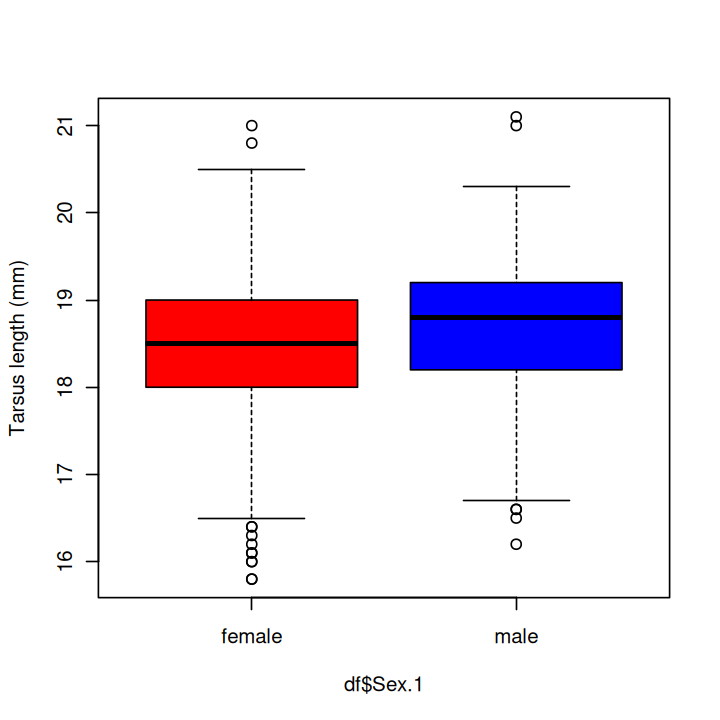

In [14]:
options(repr.plot.width = 6, repr.plot.height = 6)  # width, height in inches
boxplot(df$Tarsus~df$Sex.1, col = c("red", "blue"), ylab="Tarsus length (mm)")

On a boxplot, we can identify easily:
1. **the mean** = the thick black line in the middle of the plot
2. **the interquartile range** = the edges of the box
3. **the 95% confidence interval** = the edges of the whiskers
4. **the outliers** = the circles represent the data that lies outside the 95% CI

## 1.2) Data types
Data can be classified as **(i) numeric** or **(ii) categorical**. Numeric data can be either **continuous** or **discrete** and categorical data can be either **ranked**(ex. young, middle aged, old / cold, warmer, hot...) or **nominal** (ex. blue, red, orange...)

In [15]:
glimpse(SparrowData)

Rows: 1,770
Columns: 9
$ BirdID        <int> 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 5, 5, 5, 5, 5, 5,…
$ Year          <int> 2002, 2001, 2002, 2003, 2004, 2004, 2004, 2004, 2004, 20…
$ Tarsus        <dbl> 16.9, 16.8, 17.2, 17.5, 17.8, 17.7, 17.5, 17.8, 17.8, 17…
$ Bill          <dbl> NA, NA, NA, 13.5, 13.4, 13.1, 13.3, 13.1, 13.1, 13.3, 13…
$ Wing          <dbl> 76, 76, 76, 76, 77, 78, 77, 77, 77, 77, 78, 78, 79, 76, …
$ Mass          <dbl> 23.60, 27.50, 28.10, 27.75, 26.50, 26.00, 27.70, 26.60, …
$ Sex           <int> 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ Sex.1         <chr> "female", "male", "male", "male", "male", "male", "male"…
$ RoundedTarsus <dbl> 16.9, 16.8, 17.2, 17.5, 17.8, 17.7, 17.5, 17.8, 17.8, 17…


Looking at the data in the Sparrow dataset, we can see that *BirdID* is nominal, *Year* is discrete numeric, *Tarsus*, *Bill* and *Mass* are numeric continuous, *Wing* is numeric discrete, *Sex* and *Sex.1* are categorical nominal but  with a boolean notation in *Sex* and a character one in *Sex.1*.

Numeric data can be either **continuous** our **discrete**. In order to perform statistical testing on the data, we need adequate distributions to fit the hypothetical distribution in the population. Depending on whether the data is discrete or continuous, the reference distributions will not be the same. 

### 1.2.1) Continuous data
For continuous data, we usually use the **standard normal distribution** aloso called bell curve. The probability of this distribution is defined by *mean* and *variance*, which makes it easy to handle. However, other distributions exist, like the **log-normal** or the **exponential** curves.


Attachement du package : ‘gridExtra’


L'objet suivant est masqué depuis ‘package:dplyr’:

    combine


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


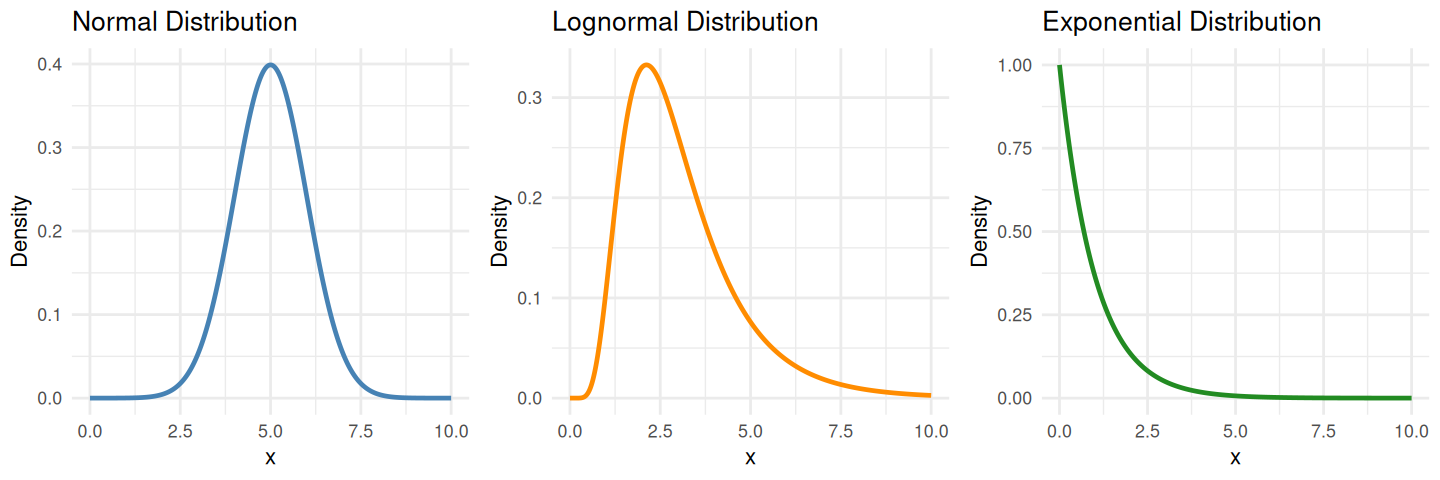

In [16]:
library(gridExtra)

# Define x-values
x <- seq(0, 10, length.out = 500)

# 1. Normal distribution (mean = 5, sd = 1)
df_norm <- data.frame(
  x = x,
  y = dnorm(x, mean = 5, sd = 1)
)

p1 <- ggplot(df_norm, aes(x, y)) +
  geom_line(color = "steelblue", size = 1) +
  labs(title = "Normal Distribution", x = "x", y = "Density") +
  theme_minimal(base_size = 13)

# 2. Lognormal distribution (meanlog = 1, sdlog = 0.5)
df_lognorm <- data.frame(
  x = x,
  y = dlnorm(x, meanlog = 1, sdlog = 0.5)
)

p2 <- ggplot(df_lognorm, aes(x, y)) +
  geom_line(color = "darkorange", size = 1) +
  labs(title = "Lognormal Distribution", x = "x", y = "Density") +
  theme_minimal(base_size = 13)

# 3. Exponential distribution (rate = 1)
df_exp <- data.frame(
  x = x,
  y = dexp(x, rate = 1)
)

p3 <- ggplot(df_exp, aes(x, y)) +
  geom_line(color = "forestgreen", size = 1) +
  labs(title = "Exponential Distribution", x = "x", y = "Density") +
  theme_minimal(base_size = 13)

# Align all three plots side by side
options(repr.plot.width = 12, repr.plot.height = 4)
grid.arrange(p1, p2, p3, ncol = 3)


#### Normal (gaussian) distribution 

**Normal distribution** is symmetrcally distributed around the mean, with mean = median = mode. The spread of the distribution is defined by the standard deviation (SD). In a normal distribution:
- Approximately 68% of the data falls within 1 SD of the mean.
- Approximately 95% of the data falls within 2 SDs of the mean.

$$ f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2} $$

where:
- \( \mu \) is the mean,
- \( \sigma \) is the standard deviation,
- \( x \) is the variable of interest.

#### Log-normal distribution

**Log-normal distribution** is a non-negative, *right-skewed* distribution meaning that it has a long tail on the right side. It is used to model data that *cannot be negative* and where values are *multiplicatively related* (ie. making log transformation pertinent as it changes it into an additive relationship). The mean, median, and mode of a log-normal distribution are not equal, with the *mean > median > mode*.

$$ f(x) = \frac{1}{\sigma \sqrt{x 2\pi}} e^{-\frac{1}{2} \left( \frac{\ln(x) - \mu}{\sigma} \right)^2} $$

where:
- \( \mu \) is the mean of the underlying normal distribution,
- \( \sigma \) is the standard deviation of the underlying normal distribution,
- \( x \) is the variable of interest.

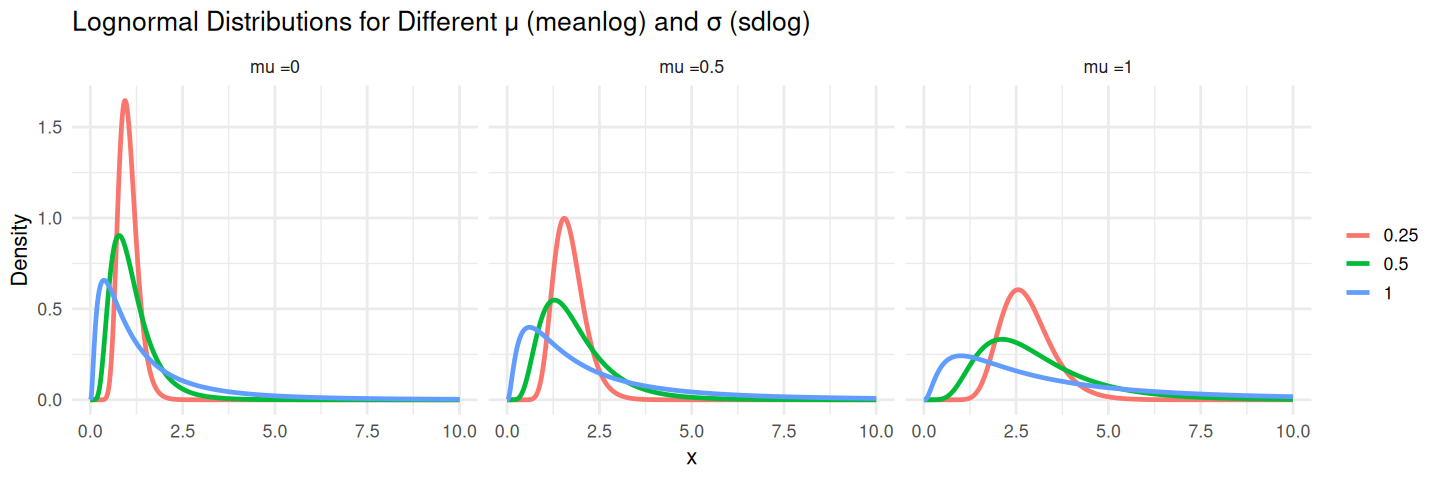

In [17]:
# Create a grid of x values
x <- seq(0, 10, length.out = 500)

# Define parameter combinations (meanlog = μ, sdlog = σ)
params <- expand.grid(
  meanlog = c(0, 0.5, 1),
  sdlog   = c(0.25, 0.5, 1)
)

# Compute density for each parameter pair
densities <- do.call(rbind, lapply(1:nrow(params), function(i) {
  data.frame(
    x = x,
    density = dlnorm(x, meanlog = params$meanlog[i], sdlog = params$sdlog[i]),
    mu = params$meanlog[i],
    sigma = params$sdlog[i]
  )
}))

# Plot
options(repr.plot.width = 12, repr.plot.height = 4)
ggplot(densities, aes(x = x, y = density, colour = factor(sigma))) +
  geom_line(size = 1) +
  facet_wrap(~ mu, labeller = label_bquote(paste('mu =', .(mu)))) +
  labs(
    title = "Lognormal Distributions for Different μ (meanlog) and σ (sdlog)",
    x = "x",
    y = "Density",
    colour = expression(sigma)
  ) +
  theme_minimal(base_size = 13)


#### Exponential distribution

**Exponential distribution** is a positive, right skewed and decreasing curve that is usually used to describes the time between independent events that occur at a constant average rate. It is defined by a single parameter, the rate $\lambda$, which determines how quickly the probability decays — higher values of $\lambda$ indicate events occur more frequently. 
$$ f(x) = \lambda e^{-\lambda x} \quad \text{for} \quad x > 0$$
meaning that the likelihood of very short intervals is high, while longer intervals are increasingly unlikely. The exponential distribution is bounded at zero, and has both its mean and standard deviation equal to $1/\lambda$. Common applications include modeling waiting times, lifetimes of components, or arrival intervals in Poisson processes.

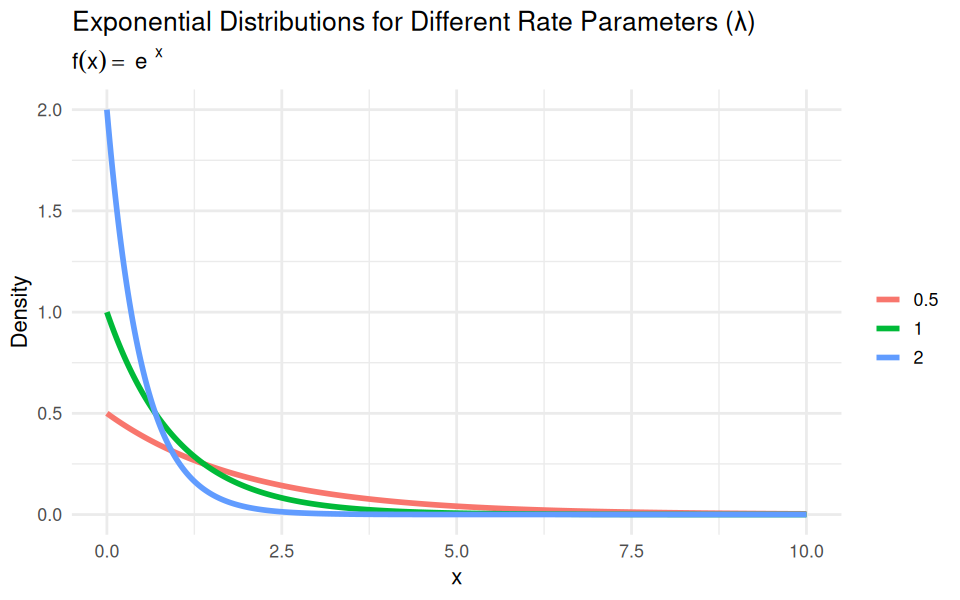

In [18]:

# Define x values
x <- seq(0, 10, length.out = 500)

# Define rate parameters
rates <- c(0.5, 1, 2)

# Compute densities for each rate
df_exp <- do.call(rbind, lapply(rates, function(r) {
  data.frame(
    x = x,
    y = dexp(x, rate = r),
    rate = factor(r)
  )
}))

options(repr.plot.width = 8, repr.plot.height = 5)
ggplot(df_exp, aes(x = x, y = y, color = rate)) +
  geom_line(size = 1.2) +
  labs(
    title = "Exponential Distributions for Different Rate Parameters (λ)",
    subtitle = expression(f(x) == lambda * e^{-lambda * x}),
    x = "x",
    y = "Density",
    color = expression(lambda)
  ) +
  theme_minimal(base_size = 13)


### 1.2.2) Discrete data

#### Binomial distribution

The **Binomial distribution** describes the number of successes $k$ in a fixed number $n$ of independent trials, each with the same probability of success $p$. It is useful for experiments with two outcomes (success/failure), such as flipping coins or testing defective items. 

$$ \mathbb{P}(X = k) = \binom{n}{k} p^{k} (1-p)^{(n-k)}$$

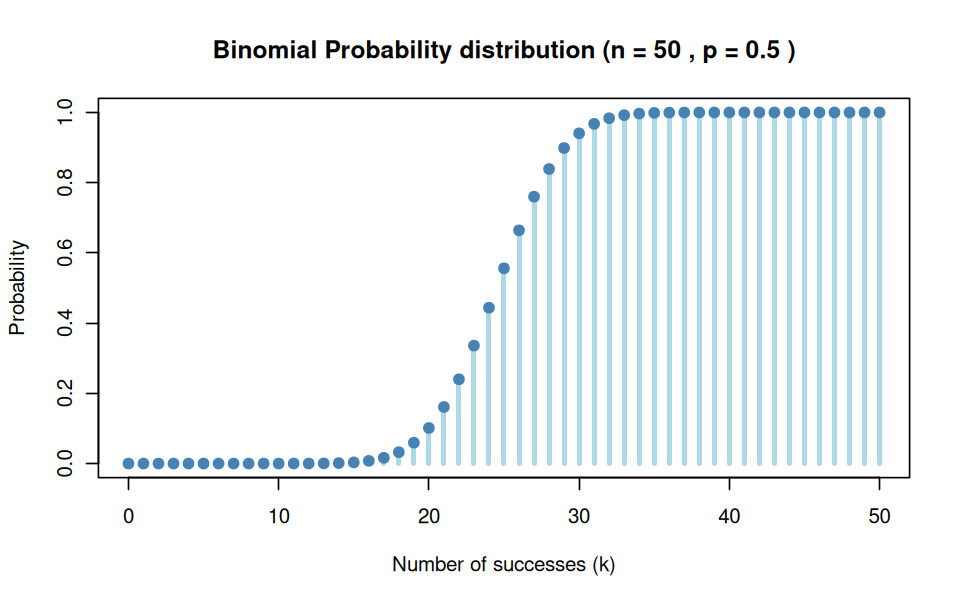

In [19]:
x = 0:50
y = pbinom(x, size = 50, prob = 0.5)
y2 = dbinom(x, size = 50, prob = 0.5)

plot(x, y, type = "h", lwd = 3, col = "lightblue",
     main = paste("Binomial Probability distribution (n =", 50, ", p =", 0.5, ")"),
     xlab = "Number of successes (k)",
     ylab = "Probability")
points(x, y, pch = 19, col = "steelblue")

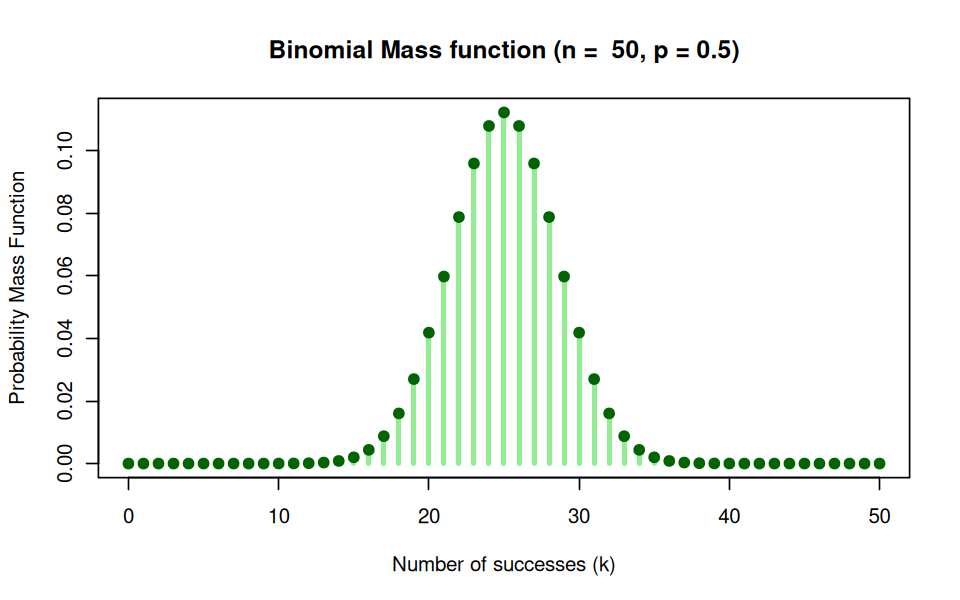

In [20]:
plot(x, y2, type= 'h', lwd = 3, col = 'lightgreen', main = 'Binomial Mass function (n =  50, p = 0.5)',
     xlab = 'Number of successes (k)',
     ylab = 'Probability Mass Function')
points(x, y2, pch = 19, col = 'darkgreen')

***NB:*** Let us recall that discrete distributions are not defined by density functions but by probability distributions. While **density functions** show *how concentrated the datq is around certain values*, the **probability plots** show the *exact probability $\mathbb{P}(X = x) vs. x$ distribution across values of $x$*. 
**Mass functions** (or **cumulative probability plots**) are the linking concept between these two notions as they are the *derivative of the density function* and the *cumulative of the probability plot*.

#### Poisson distribution

The **Poisson distribution** models the number of events that occur within a fixed interval of time or space when events happen independently at a constant average rate $\lambda$. It often applies to rare or random events, like calls received at a help desk or mutations in a gene sequence.
$$ \mathbb{P}( X = k) = e^{-\lambda} \frac{\lambda^{k}}{k!}$$

***NB:*** The time interval between poissonian events is distributed according to the emponential law.

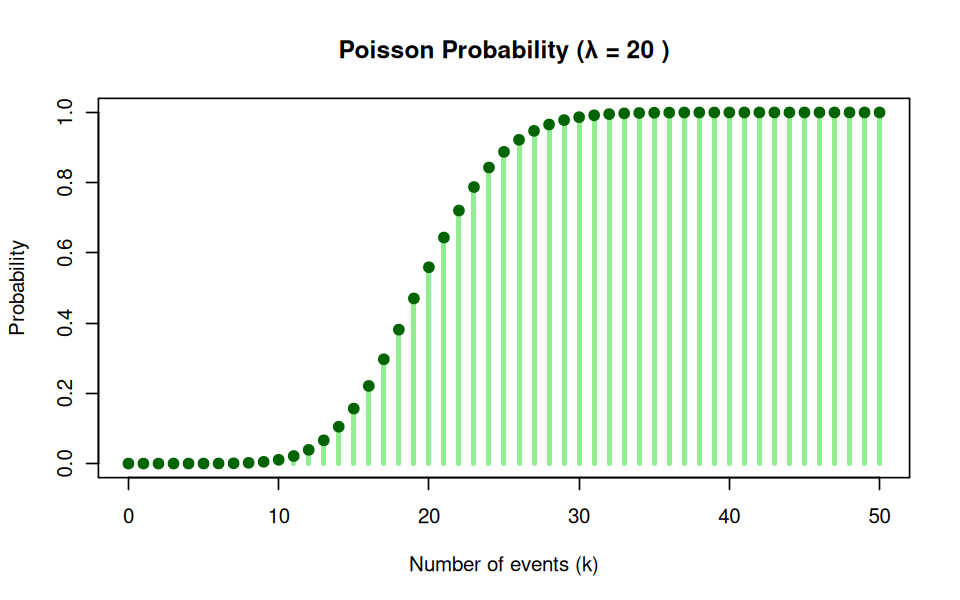

In [21]:
x = 0:50
y = ppois(x, lambda = 20)
y2 = dexp(x, rate = 1/20)

plot(x, y, type = "h", lwd = 3, col = "lightgreen",
     main = paste("Poisson Probability (λ =", 20, ")"),
     xlab = "Number of events (k)",
     ylab = "Probability")
points(x, y, pch = 19, col = "darkgreen")

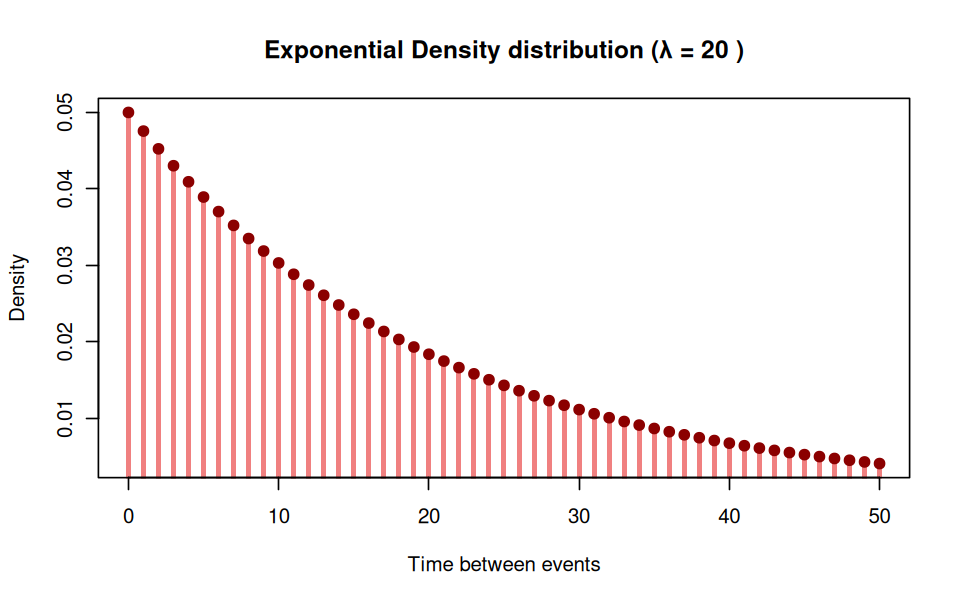

In [22]:
plot(x, y2, type = "h", lwd = 3, col = "lightcoral",
     main = paste("Exponential Density distribution (λ =", 20, ")"),
     xlab = "Time between events",
     ylab = "Density"
     )
points(x, y2, pch = 19, col = "darkred")

## 1.3) Measures of precision of an estimate

### 1.3.1) Standrard Error

The **standard error** measures *how much a sample statistic* (for instance the mean) *is expected to vary from sample to sample due to random sampling variability*. It therefore is used as a measure of how precise an estimate is.

Let's go through the formula of standard error:
$$ SE = \sqrt{\frac{\sigma^2}{n}} = \sqrt{\frac{\sum_{i=1}^n(x_i - \bar{x})^2}{(n-1)n}} \simeq \frac{\sqrt{SS}}{n}$$
which can therefore be interpreted as the ratio of total spread *versus* sample size, or in other terms, of "cost in precision" over "experimental cost". ( /!\ this interpretation is just an intuition of the mathematicl meaning behind the notion of standard error, not its *actual* definition!)


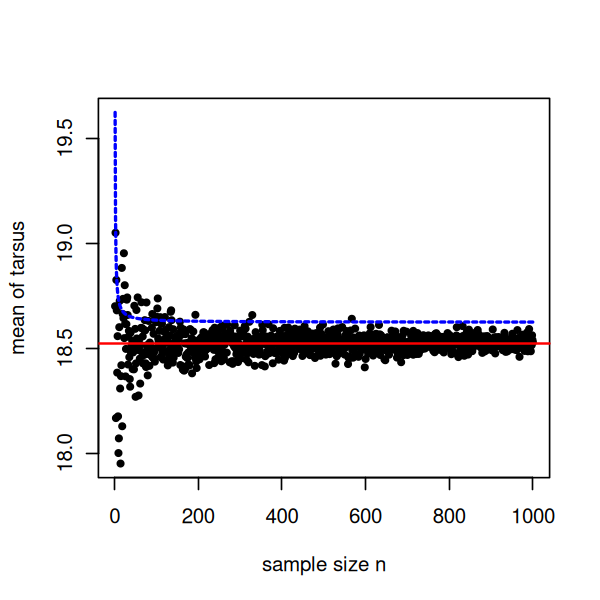

In [23]:
set.seed(123)
d = na.omit(SparrowData$Tarsus)
n <- 1:1000
means <- sapply(n, function(i) mean(sample(d, i, replace = TRUE)))

options(repr.plot.width = 5, repr.plot.height = 5)  # width, height in inches

theoretical <- 1/n + mean(d) + 0.1
yrange <- range(c(means, theoretical))

plot(n, means,
    xlab = "sample size n",
    ylab = "mean of tarsus",
    pch = 19, cex = 0.6, col = "black",
    ylim = yrange)

lines(n, theoretical, col = "blue", lty = "dashed", lwd = 2)
abline(h = mean(d), col = "red", lwd = 1.5)

The idea is driven by the seemingly inversely proportional relationship between standard deviation and sample size for any statistic estimate. 

**Standard deviation *vs.* Standard error :**

|                    | **Standard deviation  ($\sigma$)**                  | **Standard error**                     |
| --------------------------- | ------------------------------------ | ------------------------------- |
| **Definition** |  $\sqrt{1/(n-1) \sum_{i=1}^n (x_i = \bar{x})^2}$  | $\sqrt{\sigma^2/n}$          |
| **Measure**     | Variability *within a sample* | Variability *between sample estimates* |
| **Interpretation** | Describe *data spread*     | Describe *estimate precisision*                  |

***NB:*** Standard error depends on standard deviation


### 1.3.2) 95% Confidence Interval

For a given estimate, the **95% Confidence interval** is the interval that encompasses 95% of the data (ie. sampled values) from which this estimate was derived. It therefore gives a range of certainty (with 5% error) that the 'true' estimate is within these bounds. 

According to the **central limit theorem**, we get that the mean of any sample of sze $n$, chosen at random from the population follows a bell-shaped distribution centered around the *true* mean of the population such that :
$$ \bar{x} \sim \mathcal{N}(\mu, \frac{\sigma}{\sqrt{n}})$$
with $\mu$ the *true* mean of the population, $\sigma$ is the spread of the *population's* trait/value distribution.

When performing the z-transformation of the means distribution, we get that the bounds of the CI are defined by the 2.5th and 97.5th of 
$$ Z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0,1) $$
that is $q^Z_{97.5}$ = 1.96 and $q^Z_{2.5}$ = -1.96 which therefore define **the bounds of the 95% CI of the normalized sample means**.

This means that 95% of the z-transformed mean values are found within these bounds:
$$ 
\begin{align}
& \mathbb{P}(-1.96 < \frac{\bar{x} - \mu}{\sigma / \sqrt{n}} < 1.96 ) = 0.95 \\ 
\Leftrightarrow \, & \mathbb{P}(-1.96 \frac{\sigma}{\sqrt{n}} < \bar{x} - \mu < 1.96 \frac{\sigma}{\sqrt{n}} ) = 0.95 \\ 
\Leftrightarrow \, & \mathbb{P}(-1.96 SE < \bar{x} - \mu < 1.96 SE ) = 0.95 
\end{align}$$

ie. **the 95% confidence interval of the mean $\mu$ estimated by $\bar{x}$ values lies within the $\pm 1.96 SE$ interval with $SE$ the standard error of the mean estimates.**

Let's code a function to compute standard error in R.

In [24]:
StandardError = function(x) { 
    # x = numeric vector with mean estimates
    SD = sd(x,na.rm = TRUE)
    N = sum(!is.na(x))
    return(SD / sqrt(N))
}

# test on Tarsus data 
SE_tarsus = StandardError(SparrowData$Tarsus)
print(paste("Standard error of Tarsus lengths:", SE_tarsus))


[1] "Standard error of Tarsus lengths: 0.0209621095716943"


Calculate the standard error for Wing length, Bill length and Body mass *in* 2001.

In [25]:
FilteredData = subset(SparrowData, SparrowData$Year == 2001)
SE_wing = StandardError(FilteredData$Wing)
SE_bill = StandardError(FilteredData$Bill)
SE_mass = StandardError(FilteredData$Mass)

print(paste("Standard error of Wing lengths in 2001:", SE_wing))
print(paste("Standard error of Bill lengths in 2001:", SE_bill))
print(paste("Standard error of Body mass in 2001:", SE_mass))

[1] "Standard error of Wing lengths in 2001: 0.221856374881628"
[1] "Standard error of Bill lengths in 2001: NA"
[1] "Standard error of Body mass in 2001: 0.180714387357144"


## 1.4) T-tests

### 1.4.1) Hypothesis testing
Most of the time in statistics, we want to know if data is distributed according to what we believe it should be distributed given what we know. We therefore want to **test the hypothesis** that it is. 

We therefore formulate the **null hypothesis** $H_0$ against the **counter hypothesis** $H_1$ being the complementary of the null hypothsis (ie. $H_1 = \neg H_0$ in terms of logic).

As the *central limit theorem* suggests it, the estimates of any $n$-random samples are normaly distributed around the actual mean of the population with standard deviation of the curve being the standard error of the population (ie. $\bar{x} \sim \mathcal{N}(\mu , \sigma/\sqrt{n})$). If the null hypothesis is: 
$$H_0 = \text{The mean of the population is 2001}$$
then, we will consider that 95% of the sampled means can be found in the 95% confidence interval of this distribution. 

### 1.4.2) One sample t-testing
Except for the fact that **we don't know the standard error of the population**, but only that of the sampled population! To account for this small change, we use a **Student distribution** also known as **t-distriution**. This is a *"modfied standard gaussian curve"* that accounts for the extra variability arising from the use of the sample's standard error as spread parameter instead of the true standard error. Its parameter is the **degree of freedom**, which is $n-1$ in the case of the t-distribution.

The Student distribution looks very much like the Standard Gaussian one but with slightly crushed shape to emphasize the spread:

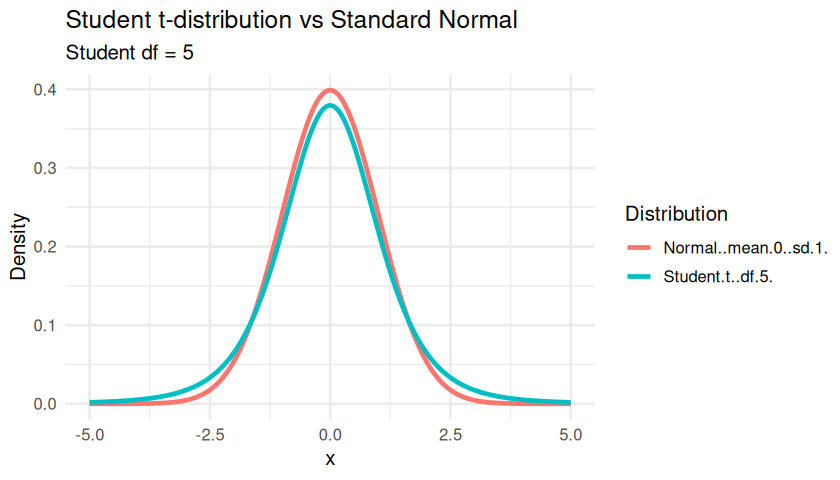

In [33]:
# Overlay Student t-distribution and standard normal on the same plot

options(repr.plot.width = 7, repr.plot.height = 4)  # adjust plot size in the notebook

# avoid overwriting existing 'x' in the notebook
xs <- seq(-5, 5, length.out = 1000)

df_t <- 5  # degrees of freedom for the Student t-distribution

dens_df <- data.frame(
    x = xs,
    `Student t (df=5)` = dt(xs, df = df_t),
    `Normal (mean=0, sd=1)` = dnorm(xs)
)

# reshape for ggplot (tidyr is already loaded in the notebook)
library(tidyr)  # safe if already loaded; otherwise this will load it without redefining data
dens_long <- pivot_longer(dens_df, cols = -x, names_to = "distribution", values_to = "density")

# plot
ggplot(dens_long, aes(x = x, y = density, color = distribution)) +
    geom_line(size = 1) +
    labs(title = "Student t-distribution vs Standard Normal",
             subtitle = paste0("Student df = ", df_t),
             x = "x",
             y = "Density",
             color = "Distribution") +
    theme_minimal(base_size = 12)

In order to get the quantiles of this distribution, we can refer to tables that give them for any degree of freedom. Good news is, when the sampled population is big enough, like in our case (length(na,omit(SparrowData$Tarsus)) = 1685), the 97.5th quantile is also 1.96 (Rq: this is because of the *weak law of large number*s!).

We can also use R...

In [38]:
nSample = length(na.omit(SparrowData$Tarsus))
t_crit <- qt(0.975, df = nSample - 1)
print(paste("Critical t-value for 95% CI", nSample - 1, "degrees of freedom:", t_crit))

[1] "Critical t-value for 95% CI 1684 degrees of freedom: 1.96137369249727"


The true mean of the population must therefore lie with 95% confidence in the $[\mu - 1,96 (\sigma_x/\sqrt{n}) ; \mu + 1,96 (\sigma_x/\sqrt{n})]$ interval (cf. 95% confidence interval part). 

Therefore, if the **empirical mean** found in our sample is **not within this interval**, then **the null hypothesis is rejected** (or the counter hypothesis is accepted) **with a margin of 5% error**.

Let us perform a test on the Tarsus lengths of our sparrows. Consider the null hypothesis that the true mean of the population is equal to 18.5. The counter hypothesis naturally writes as the true mean in *not* equal to 18.5. 

$$\text{ie.} \quad H_0 := \{ \mu = 18.5 \} $$

In [40]:
MeanSample = mean(SparrowData$Tarsus, na.rm = TRUE)
StdSample = sd(SparrowData$Tarsus, na.rm = TRUE)
nSample = length(na.omit(SparrowData$Tarsus))
t_crit <- qt(0.975, df = nSample - 1)
SESample = StdSample / sqrt(nSample)
CITrueMean = c(MeanSample - t_crit * SESample, MeanSample + t_crit * SESample)

print(paste('The sample mean is:', MeanSample))
print(paste('The degree of freedom is:', nSample - 1))

if (MeanSample < CITrueMean[1] || MeanSample > CITrueMean[2]) {
    print("Reject the null hypothesis: the true mean is not 18.5")
} else {
    print("Accept the null hypothesis: the true mean is 18.5 with 95% confidence")
}

[1] "The sample mean is: 18.5233531018576"
[1] "The degree of freedom is: 1684"


[1] "Accept the null hypothesis: the true mean is 18.5 with 95% confidence"


Another way to do this is to compute the *t-statistics*: $$t = \frac{\bar{x} - \mu}{SE_x} $$ 

and to compare it with the critical value. If $|t| > t_{crit}$ then the null hypothesis is rejected and it is accepted otherwise. 

***NB:*** This is the exact same thing as earlier but systematized and exactly what does the embedded t-test function in R.

In [43]:
t.test1 <- t.test(x = SparrowData$Tarsus, mu = 18.5)
t.test1


	One Sample t-test

data:  SparrowData$Tarsus
t = 1.1141, df = 1684, p-value = 0.2654
alternative hypothesis: true mean is not equal to 18.5
95 percent confidence interval:
 18.48224 18.56447
sample estimates:
mean of x 
 18.52335 


### 1.4.3) Two samples t-testing

We can also use t-tests to *assess the difference in estimate* (usually the mean) between two populations with *fairly equal variance*, in order to **determine if the difference is significant** or not. The principle is the same thing appart from the fact that the t-statistics write: 

$$t = \frac{ \bar{x} - \bar{y}}{\sigma_p ( \frac{1}{n_x} - \frac{1}{n_y})} $$

where $\sigma_p^2$ is the pooled variance defined as: $$ \sigma_p^2 = \frac{(n_x -1)\sigma_x + (n_y -1)\sigma_y}{n_x + n_y - 2}$$

Here, we test for $H_0 : \{ \bar{x} = \bar{y}\}$. The null hypothesis is therefore rejected if **0 is out of the 95% confidence interval**.

***NB:*** When the assumption of equal variance is not verified, another formula is used. Under R, this can be notified through the argument *var.equal = FALSE* in the *t.test* function.

In the following test, we try to assess for the difference in size distribution of the male and female sparrows, from a sample size 50:

In [45]:
x1 = na.omit(sample(SparrowData$Sex.1, 50) == "male")
x2 = na.omit(sample(SparrowData$Sex.1, 50) == "female")

t.test2 <- t.test(x = SparrowData$Tarsus[x1], y = SparrowData$Tarsus[x2], var.equal = TRUE)
t.test2


	Two Sample t-test

data:  SparrowData$Tarsus[x1] and SparrowData$Tarsus[x2]
t = -0.60819, df = 1918, p-value = 0.5431
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.10411994  0.05482831
sample estimates:
mean of x mean of y 
 18.49349  18.51814 


The hypothesis is accepted with 95% certitude.
But when we use the entire sample:

In [46]:
x1 = na.omit(SparrowData$Sex.1 == "male")
x2 = na.omit(SparrowData$Sex.1 == "female")

t.test2 <- t.test(x = SparrowData$Tarsus[x1], y = SparrowData$Tarsus[x2], var.equal = TRUE)
t.test2


	Two Sample t-test

data:  SparrowData$Tarsus[x1] and SparrowData$Tarsus[x2]
t = 3.7386, df = 1683, p-value = 0.0001912
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.07425012 0.23813673
sample estimates:
mean of x mean of y 
 18.59936  18.44317 


The null hypothesis is rejected.

### 1.4.4) P-value

Note that in both these ouputs, there is mention of the **p-value**. It measures **how strongly the data contradicts the null hypothesis**. A smaller p-value means the results are less consistent with the null and may support the alternative hypothesis. Common cutoffs for statistical significance are **0.05** and **0.01**.

In the first case, the p-value is 0.5431. This is fairly high and therefore supports the null hypothesis, that has been validated in the test, but it is not very strong either (like 0.967). But in the second case, the p-value is 0.0001912, which is very small. This means that, if the null hypothesis were true, there would be 1 chance in 1000 that the test indicated this contradictory result, which suggest that *the difference between the male and the female size distributions are **significantly** different*. 